In [149]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append('..')
import src.consNfextendedHubbard
import importlib
importlib.reload(src.consNfextendedHubbard)
from src.consNfextendedHubbard import _report_idmrg
from tenpy.models.model import CouplingMPOModel
from tenpy.networks.site import SpinHalfFermionSite

import logging 
logging.basicConfig(level=logging.INFO)
from tenpy.networks.mps import MPS
from tenpy.networks.site import SpinHalfFermionSite
from tenpy.algorithms import dmrg as tenpy_dmrg
import utils.io as io
import tenpy
print(tenpy.__version__)


1.1.0


In [175]:
class HubbardSpinDepV(CouplingMPOModel):
    """
    1D Hubbard model with spin-dependent nearest-neighbor repulsion.

    Model parameters:
        t     : float — NN hopping (default 1.0)
        U     : float — on-site Hubbard repulsion 
        Vpp   : float — V^{++} = V^{--}, same-spin NN repulsion 
        Vpm   : float — V^{+-} = V^{-+}, opposite-spin NN repulsion
                        FM condition: Vpm > Vpp
        mu    : float — chemical potential (default 0.0, half filling)
        bc_MPS    : 'infinite' or 'finite'
        L         : unit cell / chain length
    """

    def init_sites(self, model_params):
        cons_N = model_params.get("cons_N", "N")
        cons_Sz = model_params.get("cons_Sz", "None")
        return SpinHalfFermionSite(cons_N = cons_N, cons_Sz = cons_Sz)

    def init_terms(self, model_params):
        t   = model_params.get("t",   1.0)
        U   = model_params.get("U", None)
        Vpp = model_params.get("Vpp", None)   # V^{++}: same spin
        Vpm = model_params.get("Vpm", None)   # V^{+-}: opposite spin
        mu  = model_params.get("mu",  0.0)
        hx  = model_params.get("Sx", 0.0)
        hz  = model_params.get("Sz", 0.0)

        # NN hopping (plus_hc=True adds the Hermitian conjugate automatically)
        self.add_coupling(-t, 0, "Cdu", 0, "Cu", 1, plus_hc=True)
        self.add_coupling(-t, 0, "Cdd", 0, "Cd", 1, plus_hc=True)

        # On-site Hubbard U
        self.add_onsite(U, 0, "NuNd")

        # V^{++}: same-spin NN repulsion  (↑↑ and ↓↓)
        self.add_coupling(Vpp, 0, "Nu", 0, "Nu", 1)
        self.add_coupling(Vpp, 0, "Nd", 0, "Nd", 1)

        # V^{+-}: opposite-spin NN repulsion  (↑↓ and ↓↑)
        self.add_coupling(Vpm, 0, "Nu", 0, "Nd", 1)
        self.add_coupling(Vpm, 0, "Nd", 0, "Nu",   1)

        # Chemical potential
        if abs(mu) > 1e-12:
            self.add_onsite(-mu, 0, "Ntot")

        # Spin-mixing terms
        if abs(hx) > 1e-12:
            self.add_onsite(hx, 0, "Sx")
        #Spin - polarization: 
        if abs(hz) > 1e-12: 
            self.add_onsite(hz, 0, "Sz")

def run_idmrg(t=1.0, U=4.0, Vpp=0.5, Vpm=1.5, hx=0.0, hz=0.0, chi_max=100, n_sweeps=12, max_err=1e-5,
              verbose=True, psi_init=None, diagnostics=False):
    """
    Run iDMRG for HubbardSpinDepV in the thermodynamic limit.
    Unit cell L=2 (minimum for a non-trivial iMPS at half filling).
    """
    if verbose:
        print("=" * 65)
        print(f"  t={t}  U={U}  V^{{++}}={Vpp}  V^{{+-}}={Vpm}")
        print(f"  ΔV = V^{{+-}} - V^{{++}} = {Vpm-Vpp:.3f}  (>0 drives FM)")
        print("=" * 65)

    
    chi_list = {0:chi_max//2, 21: int(3*chi_max/4), 51:chi_max}
    dmrg_params = {
        "trunc_params": {
            "chi_max": chi_max,
            "svd_min": 1e-11,
            # "trunc_cut": 1e-10,
        },
        "chi_list":chi_list,
        "mixer": "DensityMatrixMixer",
        "mixer_params": {
            "amplitude": 1e-3,
            "decay": 1.2,
            "disable_after": 20, 
        },
        # "N_sweeps_check": 1,
        "min_sweeps": 30,
        "max_sweeps": n_sweeps,
        "update_env": 4,
        "start_env": 10,
        'max_E_err': max_err, #precision in energy 
        'max_S_err': max_err, #precision in entropy
    }
    model_params = dict(
        t=t, U=U, Vpp=Vpp, Vpm=Vpm, mu=0.0, hx=hx, hz=hz,
        bc_MPS="infinite",
        L=4, cons_N="N", cons_Sz="None",
    )
    model = HubbardSpinDepV(model_params)
    if not psi_init:
        # Quarter-filling, Sz=N/2 initial state
        psi = MPS.from_product_state(model.lat.mps_sites(), ["full", "empty", "empty", "empty"] , bc=model.lat.bc_MPS)
    else : 
        psi = psi_init
        chi_init = max(psi.chi)
        if chi_init > chi_max // 2: 
            dmrg_params["chi_list"] = None
            dmrg_params["mixer"] = False
            dmrg_params["start_env"] = 0


    eng = tenpy_dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    E, psi = eng.run()   # E is energy per site for iDMRG
    total_sweeps = eng.sweeps
    converged = eng.is_converged()

    if not converged and total_sweeps >= eng.options['max_sweeps']:
        print(f"Halted at maximum sweeps limit ({total_sweeps}) without fully converging.")

    results = {
        "model_params" : model_params, 
        "dmrg_params"  : dmrg_params,
        "converged"    : converged,
        }
    if verbose:
        report                  = _report_idmrg(E, psi)
        results.update(report)

    if diagnostics:
        results["diagnostics"] = {
            "sweep_stats": eng.sweep_stats,
            # "update_stats": eng.update_stats, # we don't want this because it takes up a shyat-ton of memory
            "age" : eng.update_stats["age"][::10] # just some additional compression
        }

    return E, psi, model, results

In [176]:
Etest, psitest, modeltest, resultstest = run_idmrg(1.0, 0.0, 0.0, 0.0, 
                                                   hx=1e-7, hz=0, chi_max=20, n_sweeps=100, max_err=1e-8, 
                                                   verbose=True, psi_init=None, diagnostics=True)
psitest.test_sanity()

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_N'='N'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_Sz'='None'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=4
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=0.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/tools/params.py:243: UserWarning: unused options for config HubbardSpinDepV:
['hx', 'hz']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but

  t=1.0  U=0.0  V^{++}=0.0  V^{+-}=0.0
  ΔV = V^{+-} - V^{++} = 0.000  (>0 drives FM)


INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'chi_list'={0: 10, 21: 15, 51: 20}
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'start_env'=10
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:trunc_params: reading 'chi_max'=20
INFO:tenpy.tools.params:trunc_params: reading 'svd_min'=1e-11
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<3 options>, 'mixer_params')
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'mixer'='DensityMatrixMixer'
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 0.001
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'max_sweeps'=100
INFO:tenpy.algorithms.dmrg:Running sweep with optimization
INFO:tenpy.algorithms.mps_common:Setting chi_max=10
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 0.001
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'update_env'=4
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO

Halted at maximum sweeps limit (110) without fully converging.

Ground state energy per site: E/N = -0.8985242939

Unit-cell observables:
  site        <Sz>       <Nup>       <Ndn>      <Ntot>
  --------------------------------------------------
     0   +0.001133    0.251058    0.248792    0.499850
     1   +0.000003    0.270274    0.270268    0.540542
     2   -0.001137    0.249063    0.251336    0.500399
     3   +0.000000    0.229605    0.229604    0.459209

  Mean <Sz>     = -0.000000
  Mean filling  = 0.500000  (should be 1.0 at half filling)

  Spin susceptibility (q=0 sum): χ ≈ 0.0454


dict_keys(['sweep', 'N_updates', 'E', 'Delta_E', 'S', 'Delta_S', 'max_S', 'time', 'max_trunc_err', 'max_E_trunc', 'max_chi', 'norm_err'])


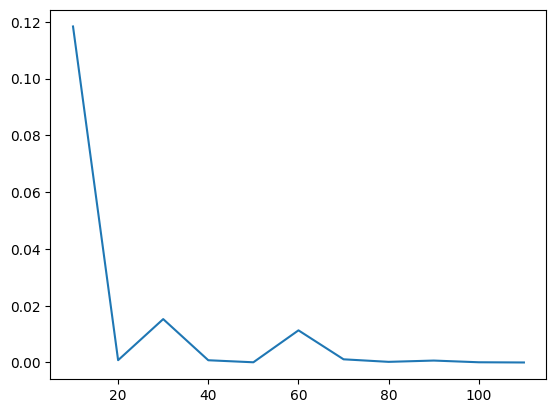

In [179]:
diags = resultstest["diagnostics"]["sweep_stats"]
print(diags.keys())
plt.plot(diags["sweep"], np.abs(diags["Delta_S"]))
# plt.yscale('log')

In [180]:
psitest.correlation_length2()

np.float64(5.1417596284251115)

In [ ]:
# t, U, Vpp = 1, 0.1, 0.8
# Vpm = Vpp + 3.00 #dV = 3, in para phase

# E, psi, model, results = run_idmrg(t=t, U=U, Vpp=Vpp, Vpm=Vpm, chi_max=20, n_sweeps=100, max_err=1e-5, verbose=False, diagnostics=True)

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_N'='N'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_Sz'='None'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=3.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(s

Halted at maximum sweeps limit (110) without fully converging.


In [104]:
print(results['diagnostics'].keys())
print(results['diagnostics']['sweep_stats'].keys())
# print(results['diagnostics']['update_stats'].keys())
diag = results["diagnostics"]["sweep_stats"]


dict_keys(['sweep_stats', 'age'])
dict_keys(['sweep', 'N_updates', 'E', 'Delta_E', 'S', 'Delta_S', 'max_S', 'time', 'max_trunc_err', 'max_E_trunc', 'max_chi', 'norm_err'])


7.081148594544301e-05


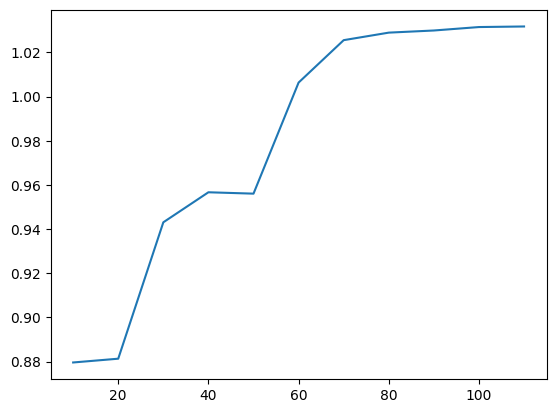

In [106]:
plt.plot(diag["sweep"], diag["S"])
# plt.plot(results["diagnostics"]["age"])
print(np.amax(diag["max_trunc_err"]))
# plt.yscale('log')

In [ ]:
# io.save_mps_with_metadata("sample_bad_conv_mps.h5", psi, results)

'sample_bad_conv_mps.h5'

In [82]:
from pympler import asizeof
print(asizeof.asizeof(results["diagnostics"]["update_stats"]["age"][::10]))
print(asizeof.asizeof(results["diagnostics"]["update_stats"]))
print(asizeof.asizeof(results))

65056
6317928
6424896


In [128]:
psi.test_sanity()
psi.canonical_form_infinite2()

INFO:tenpy.tools.params:arnoldi_params: setting 'E_tol'=np.float64(1.1334443023451489e-16)
INFO:tenpy.tools.params:arnoldi_params: reading 'E_tol'=np.float64(1.1334443023451489e-16)
